OCR avanzado para documentos empresariales
==========================================

En este notebook vamos a ver cómo se utiliza un modelo moderno de OCR/document parsing dentro de un pipeline empresarial. La idea no es solamente "leer texto", sino convertir un PDF o una imagen en una representación útil para procesos posteriores: validación de campos, revisión humana, carga a sistemas transaccionales o RAG.

Modelos recientes como Mistral OCR o DeepSeek-OCR trabajan más cerca de los modelos vision-language: reciben una página como imagen o documento, preservan parte del layout y pueden devolver Markdown, JSON o texto estructurado. Esto resulta útil cuando una factura, un contrato o un formulario contiene tablas, encabezados, sellos o información distribuida visualmente.

## Preparación del ambiente

Instalemos las dependencias necesarias desde el archivo de requerimientos asociado a este notebook. El ejemplo puede ejecutarse sin credenciales usando una respuesta simulada; si dispone de una API key de Mistral, también puede activar la llamada real al servicio.

In [ ]:
!wget -q https://raw.githubusercontent.com/santiagxf/M72109/master/docs/document-understanding/advanced-ocr-enterprise.txt
%pip install -r advanced-ocr-enterprise.txt --quiet

Recordar reiniciar la sesión si se encuentra trabajando en Google Colab y el entorno lo solicita.

## ¿Qué cambió respecto al OCR clásico?

En un pipeline clásico, primero detectamos palabras y luego intentamos reconstruir líneas, tablas y campos con reglas. En un pipeline moderno, el modelo puede producir directamente una salida más rica, por ejemplo Markdown con tablas o JSON con anotaciones. Podemos pensar el resultado como una capa intermedia entre la página visual y las aplicaciones de negocio.

A grandes rasgos, las prácticas que se repiten en sistemas empresariales son:

1. **Normalizar la entrada**: convertir PDF, imagen o escaneo en páginas procesables.
2. **Parsear el documento**: usar OCR avanzado para obtener texto, tablas, figuras y orden de lectura.
3. **Extraer estructura**: transformar el Markdown o texto en un esquema de negocio.
4. **Validar y auditar**: conservar metadatos, confianza, página de origen y evidencia visual.
5. **Integrar**: enviar los campos validados a un ERP, CRM, data lake o índice de búsqueda.

En la investigación previa se revisaron fuentes públicas de Mistral OCR, DeepSeek-OCR, PaddleOCR y MinerU. Todas apuntan a la misma dirección: documentos convertidos a Markdown/JSON, soporte para PDFs e imágenes, manejo de tablas y layouts complejos, y salidas pensadas para LLMs, RAG o flujos de automatización empresarial.

## Documento de ejemplo

Para mantener el notebook autocontenido, crearemos una factura simple como imagen. En un caso real, esta imagen podría venir de un PDF escaneado, de un correo electrónico, de un portal de proveedores o de un bucket de almacenamiento.

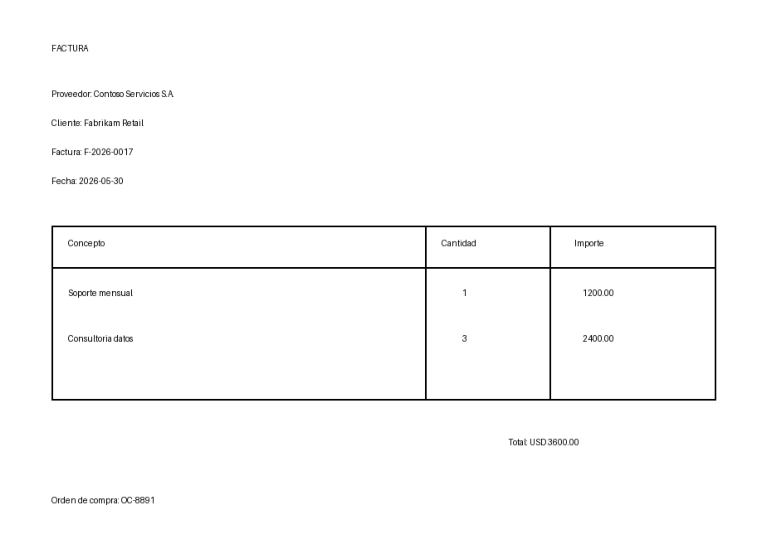

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

documento_path = Path("factura_ejemplo.png")

imagen = Image.new("RGB", (900, 650), "white")
draw = ImageDraw.Draw(imagen)
font_title = ImageFont.load_default()
font = ImageFont.load_default()

draw.text((50, 40), "FACTURA", fill="black", font=font_title)
draw.text((50, 95), "Proveedor: Contoso Servicios S.A.", fill="black", font=font)
draw.text((50, 130), "Cliente: Fabrikam Retail", fill="black", font=font)
draw.text((50, 165), "Factura: F-2026-0017", fill="black", font=font)
draw.text((50, 200), "Fecha: 2026-05-30", fill="black", font=font)

draw.rectangle((50, 260, 850, 470), outline="black", width=2)
draw.line((50, 310, 850, 310), fill="black", width=2)
draw.line((500, 260, 500, 470), fill="black", width=2)
draw.line((650, 260, 650, 470), fill="black", width=2)
draw.text((70, 275), "Concepto", fill="black", font=font)
draw.text((520, 275), "Cantidad", fill="black", font=font)
draw.text((680, 275), "Importe", fill="black", font=font)
draw.text((70, 335), "Soporte mensual", fill="black", font=font)
draw.text((545, 335), "1", fill="black", font=font)
draw.text((690, 335), "1200.00", fill="black", font=font)
draw.text((70, 390), "Consultoria datos", fill="black", font=font)
draw.text((545, 390), "3", fill="black", font=font)
draw.text((690, 390), "2400.00", fill="black", font=font)

draw.text((600, 515), "Total: USD 3600.00", fill="black", font=font_title)
draw.text((50, 585), "Orden de compra: OC-8891", fill="black", font=font)

imagen.save(documento_path)

plt.figure(figsize=(10, 7))
plt.imshow(imagen)
plt.axis("off");

## Opción 1: Mistral OCR como servicio

Mistral OCR expone una API de OCR/document parsing. El patrón típico es subir el archivo, obtener una URL firmada y procesarlo con `mistral-ocr-latest`. La respuesta contiene páginas y Markdown, y opcionalmente imágenes embebidas en base64. Note que no escribimos la API key en el notebook: se lee desde una variable de ambiente.

In [ ]:
%pip install

In [7]:
import json
import os

MISTRAL_API_KEY = "<API-KEY>" # Puede obtener una API de Mistral gratuita en https://console.mistral.ai/

from mistralai.client import Mistral
from mistralai.client.models import ImageURLChunk

client = Mistral(api_key=MISTRAL_API_KEY)

In [8]:
uploaded_file = client.files.upload(
    file={
        "file_name": documento_path.name,
        "content": documento_path.read_bytes(),
    },
    purpose="ocr",
)
signed_url = client.files.get_signed_url(file_id=uploaded_file.id, expiry=1)

In [9]:
respuesta_ocr = client.ocr.process(
    model="mistral-ocr-latest",
    document=ImageURLChunk(image_url=signed_url.url),
    include_image_base64=False,
)
respuesta_ocr = json.loads(respuesta_ocr.model_dump_json())

In [10]:
import json

print(json.dumps(respuesta_ocr, indent=2))

{
  "pages": [
    {
      "index": 0,
      "markdown": "FACTURA\n\nProveedor: Contoso Servicios S.A.\n\nCliente: Fabrikam Retail\n\nFactura: F-2026-0017\n\nFecha: 2026-05-30\n\n|  Concepto | Cantidad | Importe  |\n| --- | --- | --- |\n|  Soporte mensual | 1 | 1200.00  |\n|  Consultoria datos | 3 | 2400.00  |\n\nTotal: USD 3600.00\n\nOrden de compra: OC-8891",
      "images": [],
      "dimensions": {
        "dpi": 200,
        "height": 650,
        "width": 900
      },
      "tables": [],
      "hyperlinks": [],
      "header": null,
      "footer": null,
      "confidence_scores": null
    }
  ],
  "model": "mistral-ocr-latest",
  "usage_info": {
    "pages_processed": 1,
    "doc_size_bytes": 15957
  },
  "document_annotation": null
}


El punto importante es que el downstream ya no recibe únicamente una lista de caracteres. Recibe una representación más cercana al documento: títulos, líneas y tablas. Esto simplifica el paso siguiente, que suele ser la extracción de campos de negocio.

## Explorando la salida en Markdown

Veamos la primera página como Markdown. En documentos de muchas páginas, aquí conviene guardar también el número de página, el nombre del archivo, el hash del documento y el timestamp del procesamiento.

In [11]:
from IPython.display import Markdown, display

paginas = respuesta_ocr["pages"]
markdown_pagina = paginas[0]["markdown"]

display(Markdown(markdown_pagina))

FACTURA

Proveedor: Contoso Servicios S.A.

Cliente: Fabrikam Retail

Factura: F-2026-0017

Fecha: 2026-05-30

|  Concepto | Cantidad | Importe  |
| --- | --- | --- |
|  Soporte mensual | 1 | 1200.00  |
|  Consultoria datos | 3 | 2400.00  |

Total: USD 3600.00

Orden de compra: OC-8891

## Extracción a un esquema empresarial

En producción rara vez alcanza con guardar el Markdown completo. Normalmente se necesita un objeto con campos esperados: proveedor, factura, fecha, total, moneda y líneas de detalle. Para hacerlo explícito, definiremos un esquema con `pydantic` y una función de parsing simple. En un sistema real, esta función podría combinar reglas, LLMs con structured output o validaciones contra catálogos internos.

In [13]:
import re
from typing import List

from pydantic import BaseModel, Field


class LineaFactura(BaseModel):
    concepto: str
    cantidad: int
    importe: float


class FacturaExtraida(BaseModel):
    proveedor: str
    cliente: str
    numero_factura: str = Field(alias="factura")
    fecha: str
    moneda: str
    total: float
    orden_compra: str
    lineas: List[LineaFactura]


def buscar(pattern, texto):
    match = re.search(pattern, texto, flags=re.IGNORECASE)
    return match.group(1).strip() if match else None


def extraer_factura(markdown):
    lineas_tabla = []
    for linea in markdown.splitlines():
        if linea.startswith("|") and "---" not in linea and "Concepto" not in linea:
            celdas = [celda.strip() for celda in linea.strip("|").split("|")]
            if len(celdas) == 3:
                lineas_tabla.append(
                    LineaFactura(
                        concepto=celdas[0],
                        cantidad=int(celdas[1]),
                        importe=float(celdas[2]),
                    )
                )

    moneda, total = re.search(r"Total:\s*([A-Z]{3})\s*([0-9.]+)", markdown).groups()

    return FacturaExtraida(
        proveedor=buscar(r"Proveedor:\s*(.+)", markdown),
        cliente=buscar(r"Cliente:\s*(.+)", markdown),
        factura=buscar(r"Factura:\s*(.+)", markdown),
        fecha=buscar(r"Fecha:\s*([0-9-]+)", markdown),
        moneda=moneda,
        total=float(total),
        orden_compra=buscar(r"Orden de compra:\s*(.+)", markdown),
        lineas=lineas_tabla,
    )


factura = extraer_factura(markdown_pagina)

In [14]:
print(json.dumps(factura.model_dump(by_alias=True), indent=2))

{
  "proveedor": "Contoso Servicios S.A.",
  "cliente": "Fabrikam Retail",
  "factura": "F-2026-0017",
  "fecha": "2026-05-30",
  "moneda": "USD",
  "total": 3600.0,
  "orden_compra": "OC-8891",
  "lineas": [
    {
      "concepto": "Soporte mensual",
      "cantidad": 1,
      "importe": 1200.0
    },
    {
      "concepto": "Consultoria datos",
      "cantidad": 3,
      "importe": 2400.0
    }
  ]
}


## Validaciones de negocio

Una práctica muy importante es no confiar ciegamente en la salida del modelo. Podemos validar reglas simples: que la suma de las líneas coincida con el total, que la fecha tenga el formato esperado, que la moneda esté permitida y que los campos obligatorios existan. Estas validaciones no reemplazan al modelo; lo convierten en parte de un proceso auditable.

In [15]:
import pandas as pd

lineas_df = pd.DataFrame([linea.model_dump() for linea in factura.lineas])
suma_lineas = lineas_df["importe"].sum()

validaciones = pd.DataFrame(
    [
        {"regla": "hay proveedor", "ok": bool(factura.proveedor)},
        {"regla": "moneda permitida", "ok": factura.moneda in {"USD", "EUR", "ARS"}},
        {"regla": "total coincide con líneas", "ok": abs(suma_lineas - factura.total) < 0.01},
        {"regla": "hay orden de compra", "ok": bool(factura.orden_compra)},
    ]
)

display(lineas_df)
display(validaciones)

,concepto,cantidad,importe
0,Soporte mensual,1,1200.0
1,Consultoria datos,3,2400.0


,regla,ok
0,hay proveedor,True
1,moneda permitida,True
2,total coincide con líneas,True
3,hay orden de compra,True


## Opción 2: DeepSeek-OCR en infraestructura propia

DeepSeek-OCR es un modelo abierto orientado a OCR y conversión de documentos a Markdown. El repositorio oficial muestra dos caminos de inferencia: `vLLM` para despliegues con mayor throughput y `transformers` para pruebas más directas. En una empresa, esta opción resulta interesante cuando se requiere control de datos, despliegue privado o integración con GPU internas.

El siguiente bloque queda desactivado por defecto porque requiere GPU, memoria suficiente y dependencias específicas como `torch`, `flash-attn` o `vLLM`. Se incluye para mostrar el patrón de uso, no como paso obligatorio del notebook.

In [ ]:
import torch
from transformers import AutoModel, AutoTokenizer

model_name = "deepseek-ai/DeepSeek-OCR"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModel.from_pretrained(
    model_name,
    trust_remote_code=True,
    use_safetensors=True,
).eval().cuda().to(torch.bfloat16)

prompt = "<image>\n<|grounding|>Convert the document to markdown."
output_path = "deepseek_ocr_output"

resultado = model.infer(
    tokenizer,
    prompt=prompt,
    image_file=str(documento_path),
    output_path=output_path,
    base_size=1024,
    image_size=640,
    crop_mode=True,
    save_results=True,
)

print(resultado)

## Arquitectura de referencia

Podemos resumir el flujo empresarial de esta forma:

1. **Ingesta**: recibir PDFs o imágenes desde correo, SFTP, API o almacenamiento interno.
2. **Clasificación ligera**: identificar tipo de documento y prioridad.
3. **OCR avanzado**: procesar con un servicio como Mistral OCR o con un modelo desplegado internamente como DeepSeek-OCR, PaddleOCR o MinerU.
4. **Normalización**: convertir la salida a Markdown/JSON y adjuntar metadatos.
5. **Extracción estructurada**: mapear a esquemas de negocio.
6. **Validación**: aplicar reglas determinísticas, catálogos y umbrales de confianza.
7. **Human-in-the-loop**: derivar a revisión solo los documentos ambiguos.
8. **Persistencia**: guardar documento original, salida OCR, campos extraídos y trazabilidad.

La pregunta práctica sería: ¿qué modelo conviene elegir? Si se prioriza rapidez de adopción, un servicio administrado reduce la complejidad operativa. Si se priorizan datos sensibles, costos a escala o despliegue offline, un modelo abierto desplegado internamente puede ser más adecuado.

## Referencias consultadas

- [Mistral OCR cookbook: structured OCR](https://github.com/mistralai/cookbook/blob/main/mistral/ocr/structured_ocr.ipynb).
- [Mistral OCR cookbook: data extraction via annotations](https://github.com/mistralai/cookbook/blob/main/mistral/ocr/data_extraction.ipynb).
- [DeepSeek-OCR repository](https://github.com/deepseek-ai/DeepSeek-OCR).
- [PaddleOCR repository](https://github.com/PaddlePaddle/PaddleOCR).
- [MinerU repository](https://github.com/opendatalab/MinerU).

## Cierre

Este ejemplo muestra el patrón principal: un modelo OCR avanzado convierte el documento en una representación rica, luego una capa de extracción y validación lo transforma en datos confiables para la empresa. En producción, recuerde evaluar con documentos reales del dominio, medir errores por tipo de campo y conservar evidencia para auditoría.